In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import pickle as pkl
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
# note that here, nit using lagged/rolled features because only need to insert the values in
# previous window!\
df = pd.read_csv('../data/processed/hourly_usage_cleaned.csv')

In [3]:
# set index with multiindex
df.set_index(['client_id', 'datetime'], inplace=True)

In [4]:
# create time based features
datetimes = pd.to_datetime(df.index.get_level_values('datetime'))

df['hour'] = np.sin(2*np.pi*datetimes.hour/24)
df['day'] = np.sin(2*np.pi*datetimes.dayofweek/7)
df['month'] = np.sin(2*np.pi*datetimes.hour/12)

In [5]:
# split data into train, validation and holdout test, with 70, 10, 20 split
min_date = datetimes.min()
max_date = datetimes.max()

validation_cutoff = min_date + 0.7*(max_date - min_date)
test_cutoff = min_date + 0.8*(max_date - min_date)

# split the data

df_train = df[datetimes < validation_cutoff]
df_validation = df[(datetimes > validation_cutoff) & (datetimes < test_cutoff)]
df_test = df[datetimes > test_cutoff]

In [21]:
# fit scaler to train data nd use to transform all sets
# note that standardising the usage here, which will be the target, 
# so then need to unstandardise afterwards
# do global scaler (doing by sequence would remove magnitude info that embeddings would no 
# longer be able to learn)
scaler = StandardScaler().fit(df_train)

# use to transform train, test, validate (and into a tensor)
data_train_preprocesed = torch.tensor(scaler.transform(df_train), dtype=torch.float32)
data_validate_preprocesed = torch.tensor(scaler.transform(df_validation), dtype=torch.float32)
data_test_preprocesed = torch.tensor(scaler.transform(df_test), dtype=torch.float32)

In [ ]:
# precompute client ids so not recomputing at every timestep.
client_ids_train = df_train.index.get_level_values('client_id')
client_ids_validate = df_validation.index.get_level_values('client_id')
client_ids_test = df_test.index.get_level_values('client_id')

# create a list of client ids that are in all training, testing and validation (train misses some that are in validate/test)
client_ids_in_all_data = client_ids_train.intersection(client_ids_validate).intersection(client_ids_test)

In [ ]:
# create array to randomly sample 100 clients from the list of all clients (and for random stride in time - see later)
# need to ensure no repeat samples
num_clients = 100
rng = np.random.default_rng(seed=42)

# create random sample from client ids, ensuring no duplicates
random_client_subset = np.sort(rng.choice(client_ids_in_all_data, size=num_clients, replace=False))

# create dictionary mapping client_id to a 'embedding index', so can get index corresponding to id to use in 
# embedding layer
client_embedding_index_dict = {rand_client: i for i, rand_client in enumerate(random_client_subset)}

In [ ]:
# create dictionaries of data where key represents client and value all data for that client
# (that will access during training)

# get client data in training, validation and test for the random subset of clients to be chosen
data_train_dict = {client_id: data_train_preprocesed[client_ids_train == client_id] for client_id in random_client_subset}
data_validate_dict = {client_id: data_validate_preprocesed[client_ids_validate == client_id] for client_id in random_client_subset}
data_test_dict = {client_id: data_test_preprocesed[client_ids_test == client_id] for client_id in random_client_subset}

In [68]:
# create an index map for all possible starting indicies for sequence

# sequence length
seq_length = 24*7
# total valid number starting indexes (and thus valid number of sequences)
tot_num_start_indx_train = [data.shape[0] - seq_length for client_id, data in data_train_dict.items()]
tot_num_start_indx_validate = [data.shape[0] - seq_length for client_id, data in data_validate_dict.items()]
tot_num_start_indx_test = [data.shape[0] - seq_length for client_id, data in data_test_dict.items()]

In [69]:
np.shape(list(data_train_dict.keys()))

(100,)

In [70]:
# NOTE: taking random stride across timesteps, to ensure that sample different time points, while reducing number of data points

# random goes isnide loop here so that random stride at every iteration
index_map_train = [(client_id, start_index) for i, client_id in enumerate(random_client_subset) for start_index in range(0, tot_num_start_indx_train[i], rng.integers(low=12, high=23, size=1)[0])]
index_map_validate = [(client_id, start_index) for i, client_id in enumerate(random_client_subset) for start_index in range(0, tot_num_start_indx_validate[i], rng.integers(low=12, high=23, size=1)[0])]
index_map_test = [(client_id, start_index) for i, client_id in enumerate(random_client_subset) for start_index in range(0, tot_num_start_indx_test[i], rng.integers(low=12, high=23, size=1)[0])]

In [ ]:
len(index_map_train)
# from 190000 batches down to under 3000 through random cient sampling and stride in time series window

120026

In [ ]:
# create Dataset class to retrieve the sequences, given an index


class SeqExtractionDataSet(Dataset):

    def __init__(self, data_dict, idx_map, seq_length=24*7):
        
        # set idx map, which use to get total number of samples
        # set data dict which extract the samples from
        # set the sequence length which gives the length of each sample X_seq
        self.data_dict = data_dict
        self.idx_map = idx_map
        self.seq_length = seq_length


    def __getitem__(self, idx):
        """ take integer idx from the dataloader and return the features at all time points in 
        context window seq_length (X_seq), along with the target (y_seq) and corresponding client_id EMBEDDING
         INDEX (not the id itself).
         
        if mode set to 'train' then extracts from training set. 'validate' extracts from validation set. 'test' extracts 
        from the test set. Else gives an error.

        Note use of intermediate index map to extract sequences on a per client basis """

        # idx is a numeric integer returned by the dataloader (which it creates using length of all samples)
        # so use this integer to extract a corresponding index from index map, for a sequence
        # then extract the client_id and starting index of sequence from the corresopnding tuple
        client_id = self.idx_map[idx][0]
        seq_start_idx = self.idx_map[idx][1]

        # print(self.data_dict[client_id][seq_start_idx: seq_start_idx + self.seq_length, :].shape)
        # print(self.data_dict[client_id][seq_start_idx + self.seq_length].shape)
        # and to extract the corresponding context window and target
        X_seq = self.data_dict[client_id][seq_start_idx: seq_start_idx + self.seq_length, :]
        # for target, just want usage only
        y_seq = self.data_dict[client_id][seq_start_idx + self.seq_length, 0]

        # assume that the sequences are already in torch tensor format. client id embedding index 
        # will be used as lookup in embedding matrix so store in long format
        # NOTE: not storing client id itself here, but the index used to access its embedding in 
        # embedding matrix
        
        return X_seq, y_seq, torch.tensor(client_embedding_index_dict[client_id], dtype=torch.long)


    def __len__(self):
        """ returns the total number of samples in the Dataset. Used by dataloader """

        #TODO: need more tests for shapes compatibility etc.
        return len(self.idx_map)

In [73]:
# now create instance of the dataset for train, test, and validate
dataset_train = SeqExtractionDataSet(data_dict=data_train_dict, idx_map=index_map_train, seq_length=seq_length)
dataset_validate = SeqExtractionDataSet(data_dict=data_validate_dict, idx_map=index_map_validate, seq_length=seq_length)
dataset_test = SeqExtractionDataSet(data_dict=data_test_dict, idx_map=index_map_test, seq_length=seq_length)

batch_size = 32

# and corresponding dataloaders. Fine to shuffle because using sequences here rather than time points
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, drop_last=True)
dataloader_validate = DataLoader(dataset_validate, batch_size=32, shuffle=True, drop_last=True)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=True, drop_last=True)

In [74]:
# number of features
n_features = len(df_train.columns)
# embedding dim size
embedding_dim = 8
# hidden size in LSTM
hidden_size = 10
# num embeddings - use those in random subset
num_embeddings = len(random_client_subset)

In [ ]:
# now implement the LSTM class

# for now keep vanilla with no multiple layers
class LSTMDemand(nn.Module):

    def __init__(self, n_features, num_embeddings, embedding_dim=8, hidden_size=8):

        super().__init__()

        # embedding layer to capture client specific info
        # note this is a look up table which stores the embeddings.
        # with embedding dim embeddings for each client
        #  These embeddings are concatenated with features in the forwards pass

        # create an embedding equal to max number of clients (note that some clients are eliminated)
        # but for simplicity for now, just leave their weights unchanged (and could set to zero later)
        self.embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)

        # LSTM layer
        self.lstm = nn.LSTM(input_size=n_features + embedding_dim, hidden_size=hidden_size, batch_first=True)

        # final fully connected layer, taking hidden states and producing output value for next point in time
        self.fc = nn.Linear(in_features=hidden_size, out_features=1)
    

    def forward(self, input_seq_batch, client_ids_batch):
        
        # first need to get embeddings corresponding to client id from the input.
        # use the nn.embedding lookup, inserting client ids (which correspond to rows in the lookup matrix)
        # note minus one for python indexing
        # by default has size (batch, embedding_dim). Here place axis size 1 inbetween these, for seq dim,
        # so that shape matches that of input seq_batch
        client_embed = self.embedding(client_ids_batch).unsqueeze(1)

        # repeat embeddings across all time points in the sequence dim
        client_embed_repeated = client_embed.repeat(1, seq_length, 1)
        # to then column stack those embeddings with the features
        # concat along the features/embedding axis
        input_seq_batch_concat = torch.cat((input_seq_batch, client_embed_repeated), axis=2)

        # after this now have tensor of shape (batch_size, seq_length, num_features + embedding_dim)
        # only take first output
        lstm_output, _ = self.lstm(input_seq_batch_concat)

        # and final feedforwards layer. Note need to extract the output from the final timestep in sequence (because)
        # output form LSTM returns hidden state of final LSTM layer at all sequence timesteps
        return self.fc(lstm_output[:, -1, :]).squeeze(-1)


model = LSTMDemand(n_features=n_features, embedding_dim=embedding_dim, num_embeddings=num_embeddings, hidden_size=hidden_size)

In [88]:
# set up the optimiser
optimiser = Adam(params=model.parameters(), lr=0.1)

# use MSE for criterion as test
criterion = nn.MSELoss()

In [89]:
# create a class for early stopping

class EarlyStopping():

    def __init__(self, patience, delta):
        
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.best_model = None
        self.best_model_epoch = None
        self.no_improve_count = 0
        self.stop_training = False
    
    def check_early_stop(self, loss, model_state_dict, epoch):
        
        # in first timestep, need to account for best loss being None
        if self.best_loss is None or loss < self.best_loss - self.delta:

            # if model is improving, reset the best loss
            self.best_loss = loss
            self.best_model = model_state_dict
            self.best_model_epoch = epoch

            # and the counter
            self.no_improve_count = 0
        else:
            # otherwise increment the counter
            self.no_improve_count += 1
            # if exceeds patience, signal to end the run
            if self.no_improve_count >= self.patience:
                self.stop_training = True


In [ ]:
EPOCHS = 200
# create instnace of early stopping class
early_stop_checker = EarlyStopping(patience=3, delta=0.01)

In [91]:
# and now the main training loop

# empty list for the average validation losses (for later plotting)
loss_val_averages_list = []


# first loop over epochs
for epoch in range(EPOCHS):

    print(f'\n starting epoch {epoch}')
    model.train()
    for batch_idx, (X_seqs, labels, client_ids) in enumerate(dataloader_train):

        # do forwards pass
        predictions = model.forward(X_seqs, client_ids)

        # compute loss
        loss = criterion(predictions, labels)
        loss.backward()

        # step forwards
        optimiser.step()
        optimiser.zero_grad()
    
    print(f'training at epoch {epoch} completed')
    
    # at every other epoch
    if epoch % 2 == 0:
        
        # list of losses which will average over (reset at each validation loop)
        losses_val = []
        # at end of epoch, now evaluate the validation loss
        model.eval()
        with torch.no_grad():
            for batch_idx, (X_seqs_val, labels_val, client_ids_val) in enumerate(dataloader_validate):

                preds_val = model.forward(X_seqs_val, client_ids_val)
                losses_val.append(criterion(preds_val, labels_val).item())
            
            # after going through batches average loss across them
            losses_val_average = np.mean(losses_val)

            # and evaluate early stopping
            early_stop_checker.check_early_stop(loss=losses_val_average, epoch=epoch, model_state_dict=model.state_dict())

            # if time to stop then do so and restore best performing weights and biases
            if early_stop_checker.stop_training is True:
                print(f'early stopping criterion reached at {epoch} epochs. restoring to weights and biases at {early_stop_checker.best_model_epoch} epochs')
                model.load_state_dict(early_stop_checker.best_model)
                break
                
            # append average loss to its own list for plotting later
            loss_val_averages_list.append(losses_val_average)


 starting epoch 0
training at epoch 0 completed

 starting epoch 1
training at epoch 1 completed

 starting epoch 2
training at epoch 2 completed

 starting epoch 3
training at epoch 3 completed

 starting epoch 4
training at epoch 4 completed

 starting epoch 5
training at epoch 5 completed

 starting epoch 6
training at epoch 6 completed

 starting epoch 7
training at epoch 7 completed

 starting epoch 8
training at epoch 8 completed
early stopping criterion reached at 8 epochs. restoring to weights and biases at 2 epochs


In [ ]:
type(list(data_train_dict.keys())[0])

idx = torch.tensor(4, dtype=torch.long)

# data_train_dict[idx]

[tensor(2),
 tensor(4),
 tensor(5),
 tensor(6),
 tensor(7),
 tensor(8),
 tensor(9),
 tensor(10),
 tensor(11),
 tensor(12),
 tensor(13),
 tensor(14),
 tensor(15),
 tensor(16),
 tensor(17),
 tensor(18),
 tensor(19),
 tensor(20),
 tensor(21),
 tensor(22),
 tensor(23),
 tensor(24),
 tensor(25),
 tensor(26),
 tensor(27),
 tensor(28),
 tensor(29),
 tensor(30),
 tensor(31),
 tensor(32),
 tensor(33),
 tensor(34),
 tensor(35),
 tensor(36),
 tensor(37),
 tensor(38),
 tensor(39),
 tensor(40),
 tensor(41),
 tensor(42),
 tensor(43),
 tensor(44),
 tensor(45),
 tensor(46),
 tensor(47),
 tensor(48),
 tensor(49),
 tensor(50),
 tensor(51),
 tensor(52),
 tensor(53),
 tensor(54),
 tensor(55),
 tensor(56),
 tensor(57),
 tensor(58),
 tensor(59),
 tensor(60),
 tensor(61),
 tensor(62),
 tensor(63),
 tensor(64),
 tensor(65),
 tensor(66),
 tensor(67),
 tensor(68),
 tensor(69),
 tensor(70),
 tensor(71),
 tensor(72),
 tensor(73),
 tensor(74),
 tensor(75),
 tensor(76),
 tensor(77),
 tensor(78),
 tensor(79),
 tenso

In [196]:
24*7*52*300*2/32

163800.0

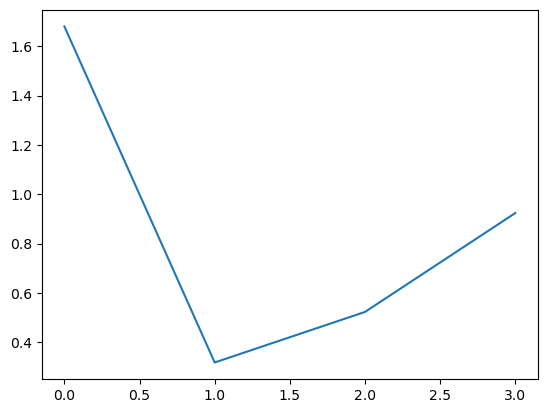

In [ ]:
# plot the loss

import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.plot(loss_val_averages_list)
plt.show()

In [ ]:
#TODO: eventually test using multiple layers in LSTM with dropout layers between them

#TODO: PCA (to identify clusters in embeddings
